In [ ]:
!pip install kagglehub

In [ ]:
import os
import kagglehub
import shutil
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
# Dataset 1
dataset1_path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

# Dataset 2
dataset2_path = kagglehub.dataset_download(
    "deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2"
)

print(dataset1_path)
print(dataset2_path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.


100%|██████████| 524M/524M [00:33<00:00, 16.3MB/s]

Extracting files...


/kaggle/input/eye-diseases-classification
/root/.cache/kagglehub/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/versions/4


In [ ]:
dataset1 = os.path.join(dataset1_path, "dataset")
dataset2 = os.path.join(dataset2_path, "eyepac-light-v2-512-jpg")

In [ ]:
merged_dataset = "/content/merged_glaucoma_dataset"

splits = ["train", "validation", "test"]
classes = ["RG", "NRG"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(merged_dataset, split, cls), exist_ok=True)

In [ ]:
for split in splits:
    for cls in classes:

        src = os.path.join(dataset2, split, cls)
        dst = os.path.join(merged_dataset, split, cls)

        if os.path.exists(src):
            for img in os.listdir(src):
                shutil.copy(os.path.join(src, img), dst)

In [ ]:
glaucoma_path = os.path.join(dataset1, "glaucoma")
normal_path = os.path.join(dataset1, "normal")

glaucoma_images = [os.path.join(glaucoma_path, f) for f in os.listdir(glaucoma_path)]
normal_images = [os.path.join(normal_path, f) for f in os.listdir(normal_path)]

In [ ]:
g_train, g_temp = train_test_split(glaucoma_images, test_size=0.3, random_state=42)
g_val, g_test = train_test_split(g_temp, test_size=0.5, random_state=42)

n_train, n_temp = train_test_split(normal_images, test_size=0.3, random_state=42)
n_val, n_test = train_test_split(n_temp, test_size=0.5, random_state=42)

In [ ]:
def copy_images(images, split, cls):

    dst = os.path.join(merged_dataset, split, cls)

    for img in images:
        shutil.copy(img, dst)


copy_images(g_train, "train", "RG")
copy_images(g_val, "validation", "RG")
copy_images(g_test, "test", "RG")

copy_images(n_train, "train", "NRG")
copy_images(n_val, "validation", "NRG")
copy_images(n_test, "test", "NRG")

In [ ]:
for split in splits:
    for cls in classes:

        folder = os.path.join(merged_dataset, split, cls)

        print(split, cls, len(os.listdir(folder)))

train RG 4704
train NRG 4751
validation RG 536
validation NRG 546
test RG 537
test NRG 547


In [ ]:
train_dir = "/content/merged_glaucoma_dataset/train"
val_dir = "/content/merged_glaucoma_dataset/validation"
test_dir = "/content/merged_glaucoma_dataset/test"

In [ ]:
IMG_SIZE = (256,256)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    shear_range=0.15
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 9455 images belonging to 2 classes.
Found 1082 images belonging to 2 classes.
Found 1084 images belonging to 2 classes.


In [ ]:
def transformer_block(x):

    attention = MultiHeadAttention(
        num_heads=8,
        key_dim=64
    )(x, x)

    x = Add()([x, attention])
    x = LayerNormalization()(x)

    ffn = Dense(512, activation="relu")(x)
    ffn = Dense(x.shape[-1])(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    return x


In [ ]:
input_tensor = Input(shape=(256,256,3))

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt = tf.exp(-bce)
        focal = alpha * (1 - pt) ** gamma * bce
        return focal
    return loss


# VGG16
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=input_tensor
)

for layer in vgg_base.layers[:-10]:
    layer.trainable = False

vgg_gap = GlobalAveragePooling2D()(vgg_base.output)
vgg_gmp = GlobalMaxPooling2D()(vgg_base.output)
vgg_features = Concatenate()([vgg_gap, vgg_gmp])


# DenseNet
dense_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_tensor=input_tensor
)

for layer in dense_base.layers[:-25]:
    layer.trainable = False

dense_gap = GlobalAveragePooling2D()(dense_base.output)
dense_gmp = GlobalMaxPooling2D()(dense_base.output)
dense_features = Concatenate()([dense_gap, dense_gmp])

# Combine features
combined = Concatenate()([vgg_features, dense_features])

combined = BatchNormalization()(combined)

combined = Dense(1024, activation="relu")(combined)
combined = Dropout(0.5)(combined)

combined = Dense(512, activation="relu")(combined)


combined = Reshape((8,64))(combined)


# Transformer
combined = transformer_block(combined)

combined = Flatten()(combined)


# Classifier
x = Dense(256, activation="relu")(combined)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)


model = Model(inputs=input_tensor, outputs=output)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss=focal_loss(),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 25,799,425 (98.42 MB)

 Trainable params: 18,135,041 (69.18 MB)

 Non-trainable params: 7,664,384 (29.24 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_glaucoma_hybrid_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint]
)

# Optional: also save final model
model.save("final_glaucoma_hybrid_model.h5")

Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.5996 - auc: 0.6345 - loss: 0.0510 - val_accuracy: 0.6978 - val_auc: 0.7730 - val_loss: 0.0365
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 237s 799ms/step - accuracy: 0.6731 - auc: 0.7340 - loss: 0.0397 - val_accuracy: 0.7708 - val_auc: 0.8413 - val_loss: 0.0320
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 240s 811ms/step - accuracy: 0.7014 - auc: 0.7721 - loss: 0.0369 - val_accuracy: 0.7551 - val_auc: 0.8571 - val_loss: 0.0325
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 239s 806ms/step - accuracy: 0.7389 - auc: 0.8211 - loss: 0.0333 - val_accuracy: 0.8179 - val_auc: 0.8899 - val_loss: 0.0297
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 240s 809ms/step - accuracy: 0.7870 - auc: 0.8657 - loss: 0.0298 - val_accuracy: 0.7616 - val_auc: 0.9137 - val_loss: 0.0316
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 241s 814ms/step - accuracy: 0.8032 - auc: 0.8857 - loss: 0.0278 - val_accuracy: 0.7172 - val_auc: 0.9309 - val_loss: 0.0343
Epoch 7/50
296/296 

In [ ]:
# Final metrics from last epoch
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_auc = history.history['auc'][-1]
final_val_auc = history.history['val_auc'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("===== FINAL RESULTS =====")
print(f"Train Accuracy  : {final_train_acc:.4f}")
print(f"Validation Accuracy : {final_val_acc:.4f}")
print(f"Train AUC : {final_train_auc:.4f}")
print(f"Validation AUC : {final_val_auc:.4f}")
print(f"Train Loss : {final_train_loss:.4f}")
print(f"Validation Loss : {final_val_loss:.4f}")


===== FINAL RESULTS =====
Train Accuracy  : 0.9507
Validation Accuracy : 0.9261
Train AUC : 0.9901
Validation AUC : 0.9793
Train Loss : 0.0085
Validation Loss : 0.0138


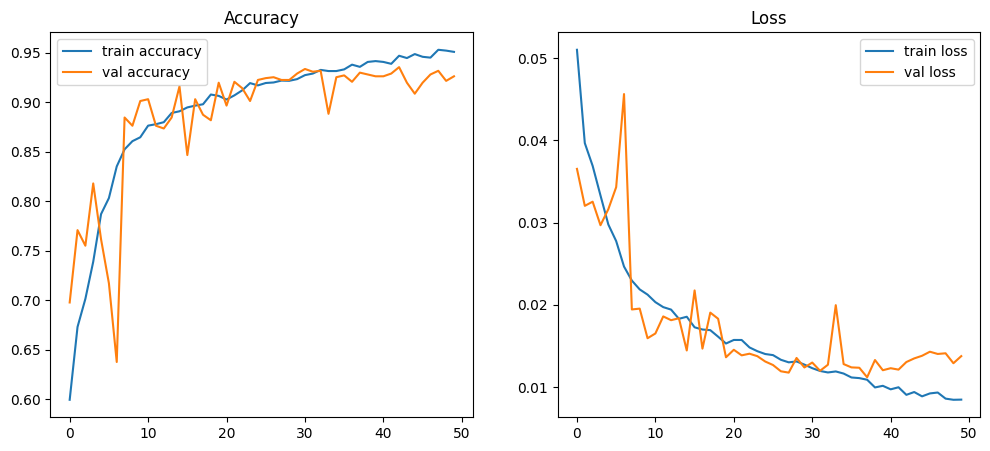

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")

plt.show()


34/34 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step
Optimal threshold: 0.49497327


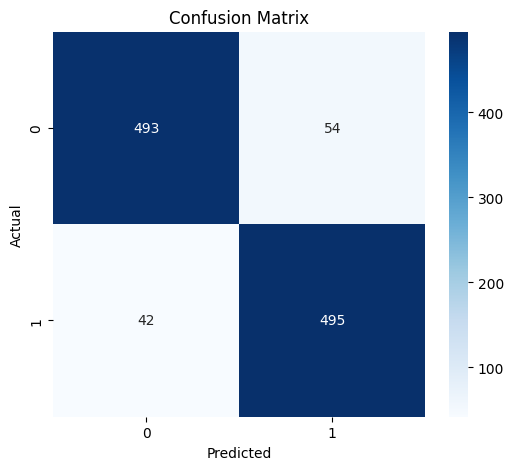

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       547
           1       0.90      0.92      0.91       537

    accuracy                           0.91      1084
   macro avg       0.91      0.91      0.91      1084
weighted avg       0.91      0.91      0.91      1084



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
import seaborn as sns

pred = model.predict(test_generator)

y_true = test_generator.classes

fpr, tpr, thresholds = roc_curve(y_true, pred)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)

y_pred = (pred > optimal_threshold).astype(int)


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print(classification_report(y_true, y_pred))


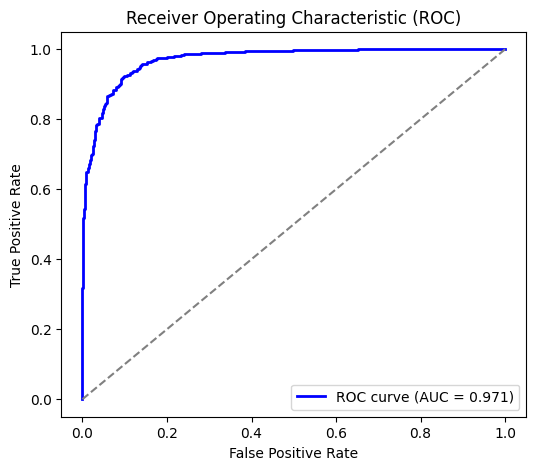

0

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, pred)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, color="blue", lw=2,
         label="ROC curve (AUC = %0.3f)" % roc_auc)

plt.plot([0,1], [0,1], color="gray", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")

plt.show()
00

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
# ── Grad-CAM Imports ──────────────────────────────────────
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow.keras.preprocessing import image as keras_image

In [ ]:
# ── Layer name constants ──────────────────────────────────
# DenseNet121 last spatial conv  (verify: [l.name for l in dense_base.layers[-5:]])
DENSENET_LAST_CONV = "conv5_block16_2_conv"   # output: (8,8,1024) for 256-input
VGG_LAST_CONV      = "block5_conv3"           # output: (8,8,512)  for 256-input


def build_branch_grad_models(model, dense_base, vgg_base):
    """
    Build two grad models that output:
        [last_conv_feature_map,  final_prediction]
    Taps the conv feature maps BEFORE pooling so spatial info is preserved.
    """
    dense_grad_model = tf.keras.Model(
        inputs  = model.input,
        outputs = [dense_base.get_layer(DENSENET_LAST_CONV).output, model.output]
    )
    vgg_grad_model = tf.keras.Model(
        inputs  = model.input,
        outputs = [vgg_base.get_layer(VGG_LAST_CONV).output, model.output]
    )
    return dense_grad_model, vgg_grad_model

In [ ]:
def compute_gradcam_heatmap(img_array, grad_model, class_idx=0):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise RuntimeError("Gradient is None.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    clip_max = tf.reduce_mean(pooled_grads) + 1.5 * tf.math.reduce_std(pooled_grads)
    pooled_grads = tf.clip_by_value(pooled_grads, clip_value_min=0, clip_value_max=clip_max)

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap).numpy()

    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    heatmap = cv2.resize(heatmap, (256, 256), interpolation=cv2.INTER_CUBIC)
    heatmap = cv2.GaussianBlur(heatmap, (5, 5), 0)

    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return heatmap.astype(np.float32)

In [ ]:
def blend_heatmaps(heatmap_dense, heatmap_vgg, alpha=0.5):
    """Resize and blend two heatmaps. alpha = DenseNet weight."""
    h, w = heatmap_dense.shape[:2]
    hm_v = cv2.resize(heatmap_vgg, (w, h), interpolation=cv2.INTER_LINEAR)
    blended = alpha * heatmap_dense + (1 - alpha) * hm_v
    if blended.max() > 0:
        blended /= blended.max()
    return blended.astype(np.float32)


def get_retina_circle_mask(img_bgr, target_size=(256, 256)):
    img_r = cv2.resize(img_bgr, target_size)
    gray  = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)

    # Larger kernel to fully close the retinal boundary
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,  kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros((target_size[1], target_size[0]), dtype=np.uint8)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)

    # REMOVED the erosion step — it was shrinking the mask inward

    return mask.astype(bool)

def overlay_heatmap_on_image(original_img_bgr, heatmap,
                              target_size=(256, 256),
                              alpha=0.45,
                              colormap=cv2.COLORMAP_INFERNO):
    img_r = cv2.resize(original_img_bgr, target_size)

    gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    retina_mask = gray > 15

    hm_r  = heatmap if heatmap.shape[:2] == (256, 256) else \
            cv2.resize(heatmap, target_size, interpolation=cv2.INTER_CUBIC)
    hm_u8  = np.uint8(255 * hm_r)
    hm_col = cv2.applyColorMap(hm_u8, colormap)
    hm_col[~retina_mask] = 0

    superimposed = cv2.addWeighted(img_r, 1 - alpha, hm_col, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

In [ ]:
def display_gradcam_hybrid(img_path, model, dense_base, vgg_base,
                            blend_alpha=0.5, overlay_alpha=0.45,
                            target_size=(256, 256)):
    """
    Full Grad-CAM pipeline for the hybrid DenseNet+VGG+Transformer model.
    Displays: Original | DenseNet Grad-CAM | VGG16 Grad-CAM | Blended Grad-CAM
    """
    # Load & preprocess
    img      = keras_image.load_img(img_path, target_size=target_size)
    arr      = np.expand_dims(keras_image.img_to_array(img), 0) / 255.0

    # Build grad models
    dense_gm, vgg_gm = build_branch_grad_models(model, dense_base, vgg_base)

    # Compute heatmaps
    hm_d  = compute_gradcam_heatmap(arr, dense_gm)
    hm_v  = compute_gradcam_heatmap(arr, vgg_gm)
    hm_b  = blend_heatmaps(hm_d, hm_v, alpha=blend_alpha)

    # Prediction
    score = model.predict(arr, verbose=0)[0, 0]
    label = "Glaucoma (RG)" if score >= 0.5 else "No Glaucoma (NRG)"

    # Overlays
    orig_bgr = cv2.imread(img_path)
    panels = [
        (cv2.cvtColor(cv2.resize(orig_bgr, target_size), cv2.COLOR_BGR2RGB),
         "Original Fundus Image"),
        (overlay_heatmap_on_image(orig_bgr, hm_d, target_size, overlay_alpha),
         f"DenseNet121 Grad-CAM\n({DENSENET_LAST_CONV})"),
        (overlay_heatmap_on_image(orig_bgr, hm_v, target_size, overlay_alpha),
         f"VGG16 Grad-CAM\n({VGG_LAST_CONV})"),
        (overlay_heatmap_on_image(orig_bgr, hm_b, target_size, overlay_alpha),
         f"Blended Grad-CAM (α={blend_alpha})"),
    ]

    fig = plt.figure(figsize=(20, 5))
    gs  = gridspec.GridSpec(1, 4, wspace=0.05)
    for i, (panel, title) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(panel)
        ax.set_title(title, fontsize=10, pad=6)
        ax.axis("off")

    fig.suptitle(
        f"Grad-CAM  |  Prediction: {label}  (score = {score:.4f})",
        fontsize=13, fontweight="bold", y=1.02
    )
    sm = plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1))
    sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, fraction=0.012, pad=0.01).set_label(
        "Activation intensity", fontsize=9)

    plt.tight_layout()
    plt.savefig("gradcam_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPrediction: {label}  |  Score: {score:.4f}")

/tmp/ipykernel_14596/2843897254.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


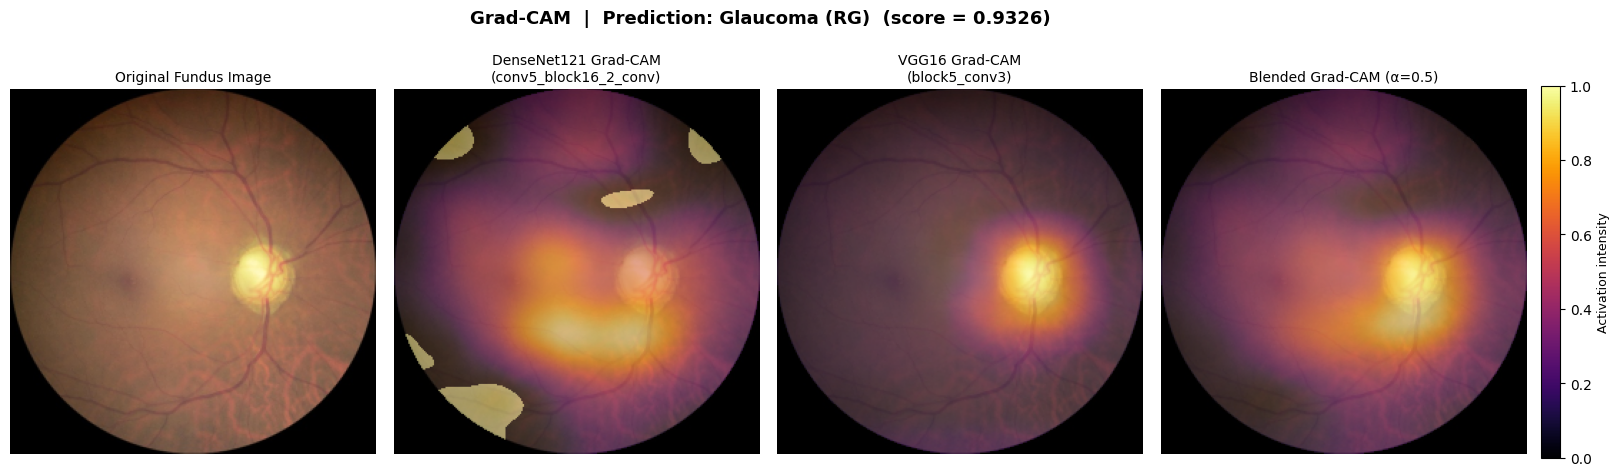


Prediction: Glaucoma (RG)  |  Score: 0.9326


In [ ]:
# ── Run Grad-CAM ─────────────────────────────────────────
img_path = "/content/merged_glaucoma_dataset/test/RG/EyePACS-TRAIN-RG-2898.jpg"

display_gradcam_hybrid(
    img_path      = img_path,
    model         = model,
    dense_base    = dense_base,   # DenseNet121 sub-model defined in Cell 4
    vgg_base      = vgg_base,     # VGG16 sub-model defined in Cell 4
    blend_alpha   = 0.5,          # 50% DenseNet + 50% VGG16
    overlay_alpha = 0.45,         # heatmap transparency
)